In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

## Get the information

In [2]:
train=pd.read_csv("train.csv")
test=pd.read_csv("test.csv")

test_1=pd.read_csv("test.csv")

## Have a look at the data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

,PassengerId,Pclass,SibSp,Parch,Fare,Survived,Age,family_members,yoro
PassengerId,1.000000,-0.035144,-0.057527,-0.001652,0.012658,-0.005007,0.034212,-0.040143,-0.028117
Pclass,-0.035144,1.000000,0.083081,0.018443,-0.549500,-0.338481,-0.339898,0.065997,0.038874
SibSp,-0.057527,0.083081,1.000000,0.414838,0.159651,-0.035322,-0.233296,0.890712,0.299059
Parch,-0.001652,0.018443,0.414838,1.000000,0.216225,0.081629,-0.172482,0.783111,0.312660
Fare,0.012658,-0.549500,0.159651,0.216225,1.000000,0.257307,0.096688,0.217138,0.011647
Survived,-0.005007,-0.338481,-0.035322,0.081629,0.257307,1.000000,-0.064910,0.016639,0.084928
Age,0.034212,-0.339898,-0.233296,-0.172482,0.096688,-0.064910,1.000000,-0.245619,-0.281441
family_members,-0.040143,0.065997,0.890712,0.783111,0.217138,0.016639,-0.245619,1.000000,0.360596
yoro,-0.028117,0.038874,0.299059,0.312660,0.011647,0.084928,-0.281441,0.360596,1.000000


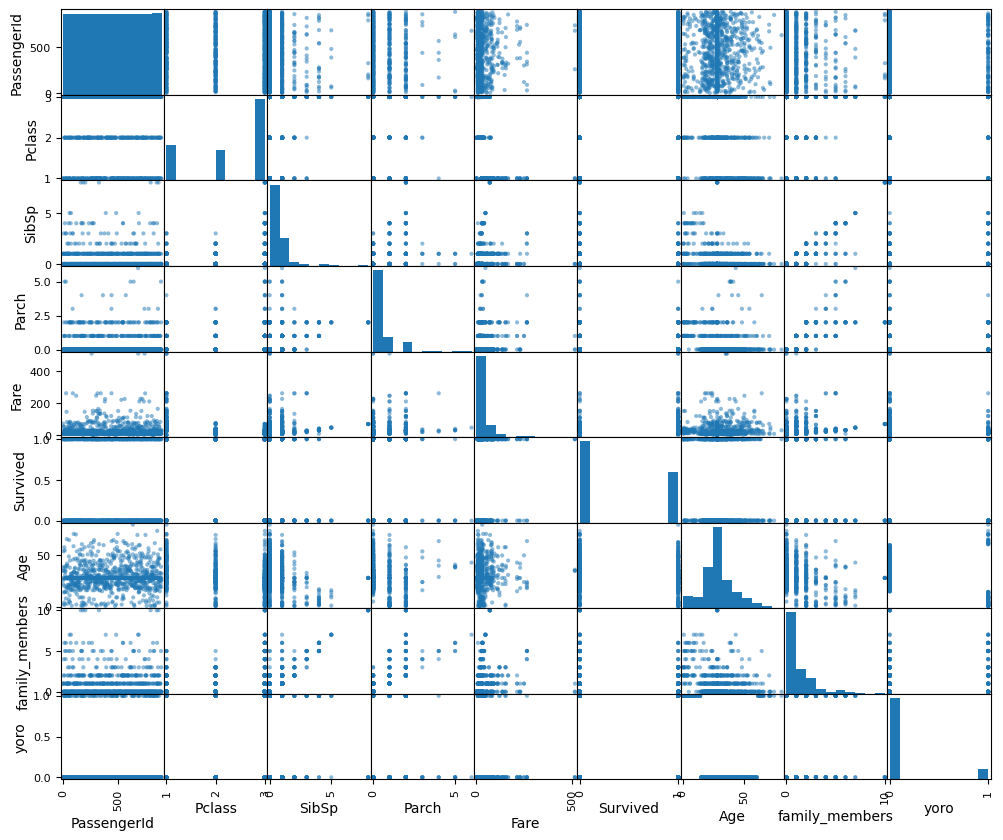

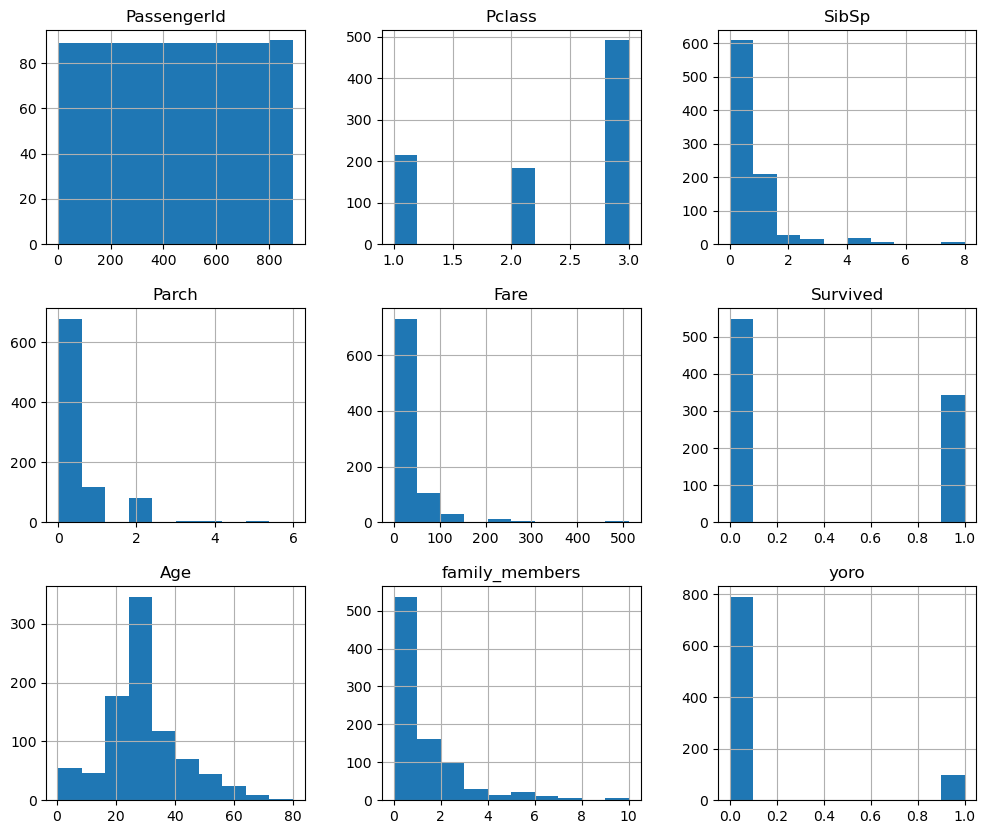

In [3]:
display(train.head())
display(train.describe())
display(train.info())
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="median")
imputer.fit(train[["Age"]])
train["Age"]=imputer.transform(train[["Age"]]).ravel()
train['family_members']=train['SibSp']+train['Parch']
train['yoro']=((train["Age"]<15) | (train["Age"]>60)).astype(int) #creat the feature
train_n=train[['PassengerId','Pclass','SibSp','Parch','Fare','Survived',"Age",'family_members','yoro']] #select the feature of number
display(train_n.corr())
from pandas.plotting import scatter_matrix
scatter_matrix(train_n,figsize=(12,10))
plt.show()
train_n.hist(figsize=(12,10))
plt.show()

## Choose the feature of number and category

In [4]:
train_y=train["Survived"]
train_x_n=train_n.drop(columns=["Survived","PassengerId",'SibSp','Parch'])
train_x_=train.drop(columns=train_n.columns)
train_x_c=train_x_.drop(columns=["Name",'Cabin','Ticket'])
train_x=pd.concat([train_x_n,train_x_c],axis=1)
train_x

,Pclass,Fare,Age,family_members,yoro,Sex,Embarked
0,3,7.2500,22.0,1,0,male,S
1,1,71.2833,38.0,1,0,female,C
2,3,7.9250,26.0,0,0,female,S
3,1,53.1000,35.0,1,0,female,S
4,3,8.0500,35.0,0,0,male,S
...,...,...,...,...,...,...,...
886,2,13.0000,27.0,0,0,male,S
887,1,30.0000,19.0,0,0,female,S
888,3,23.4500,28.0,3,0,female,S
889,1,30.0000,26.0,0,0,male,C


## Set the pipeline

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,FunctionTransformer
from sklearn.compose import make_column_transformer
from sklearn.model_selection import cross_val_predict,cross_val_score
log_transformer=FunctionTransformer(func=np.log1p,inverse_func=np.expm1)
pipeline_1=make_pipeline(OneHotEncoder(),StandardScaler(with_mean=False))
pipeline_2=make_pipeline(OrdinalEncoder(),StandardScaler(with_mean=False))
pipeline_3=make_pipeline(SimpleImputer(strategy="median"),log_transformer,StandardScaler())
columntransformer=make_column_transformer((pipeline_1,["Sex"]),(pipeline_2,["Embarked"]),(pipeline_3,["Pclass",'Fare',"Age","family_members",'yoro']))
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(random_state=42)
model=make_pipeline(columntransformer,rfc)

## Try to set the best argument for model

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
model
rand_distribution=[{"randomforestclassifier__n_estimators":randint(100,500),
                    "randomforestclassifier__max_depth":randint(0,50),
                    "randomforestclassifier__max_features":['sqrt','log2',None]}]
rsearch=RandomizedSearchCV(estimator=model,param_distributions=rand_distribution,n_iter=100)
rsearch.fit(X=train_x,y=train_y)

d:\Anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
5 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Anaconda\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Anaconda\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "d:\Anaconda\Lib\site-packages\sklearn\pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
    ~~~~~~~~~~~~~~

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"[{'randomforestclassifier__max_depth': <scipy.stats....0013BE30F8E10>, 'randomforestclassifier__max_features': ['sqrt', 'log2', ...], 'randomforestclassifier__n_estimators': <scipy.stats....0013BE305B8C0>}]"
,n_iter,100
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


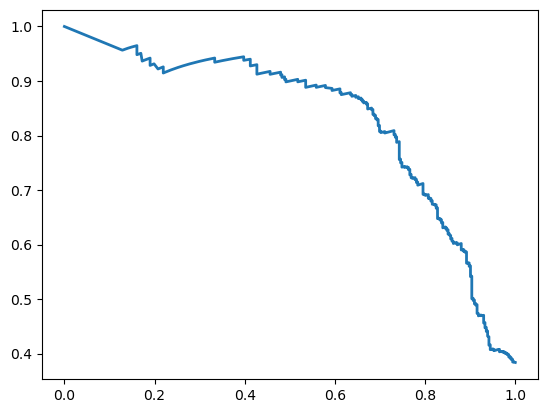

In [7]:
from sklearn.metrics import precision_recall_curve
final_model=rsearch.best_estimator_
y_prediction=(cross_val_predict(estimator=final_model,X=train_x,y=train_y,cv=3,method="predict_proba"))[:,1]
prediction,recall,threshods=precision_recall_curve(y_true=train_y,y_score=y_prediction)
plt.plot(recall,prediction,linewidth=2)
plt.show()


In [8]:
index=(prediction>0.85).argmax()
threshod=threshods[index]

In [9]:
test
test["family_members"]=test['SibSp'] + test['Parch']
test["Age"]=imputer.transform(test[["Age"]]).ravel()
test['yoro']=((test["Age"]<15) | (test["Age"]>60)).astype(int) 
test.drop(columns=["SibSp",'Parch','PassengerId','Name','Ticket','Cabin'],inplace=True)

In [12]:
answer=(((final_model.predict_proba(test))[:,1]>threshod).astype(int))
answer=pd.Series(answer,index=test_1["PassengerId"],name="Survived")
answer.to_csv("prediction")
